In [1]:
import lsdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nested_pandas as npd
import multiband_fit_template_numba as mbft
from scipy.signal import find_peaks
import importlib
from astropy.timeseries import LombScargle, LombScargleMultiband
import time

/astro/users/scharney/.conda/envs/lsdb/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
obj = lsdb.open_catalog('/epyc/data3/hats/catalogs/dp1/object_collection') # DP1 Object catalog
dia = lsdb.open_catalog('/epyc/data3/hats/catalogs/dp1/dia_object_collection', columns='all') # DP1 DiaObject catalog
photoz = lsdb.open_catalog('/epyc/data3/hats/catalogs/dp1/object_photoz') #DP1 Photo-zs catalog

In [3]:
gaia_df = pd.read_csv("/epyc/data3/rr-lyrae/CDS_download_gaia_rrlyrae.tsv", sep = '\t', header=0, skiprows=lambda x: x in [50,51], comment='#')
gaia_df

,Harm,Source,SolID,PF,e_PF,P1O,Gmagavg,BPmagavg,RPmagavg,[M/H],R21G,R31G,phi21G,phi31G,FundFreq1,FundFreq2,Class,AG,RA_ICRS,DE_ICRS
0,Harm,1000146253713924352,375316653866487565,,,0.31374834794624701,18.280980,18.3753220,17.9789920,,0.117686250,,4.5030994,,3.187268,,RRc,,103.134722,56.122426
1,Harm,1000148246578725632,375316653866487565,,,0.36000320113080142,18.648659,18.8786680,18.2794230,,0.134612980,,4.9763170,,2.777753,,RRc,,102.900343,56.093749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271777,Harm,999642681684392064,375316653866487565,0.41483990443196961,4.411711000e-06,,14.451152,14.7076050,14.0934490,1.407880300e-02,0.584834000,0.244060780,4.2594433,2.314069700,2.410568,,RRab,1.605502200e-01,90.341835,59.264482
271778,Harm,99988251695886848,375316653866487565,0.54977018337473005,3.233648700e-05,,17.833637,18.2287480,17.5089930,,0.361005130,,3.5667396,,1.818942,,RRab,-6.804591400e-02,34.923392,22.184580


In [4]:
gaia_cat = lsdb.from_dataframe(
    gaia_df,
    catalog_name="gaia",
    ra_column="RA_ICRS",
    dec_column="DE_ICRS",
    catalog_type="object")

gaia_cat

,Harm,Source,SolID,PF,e_PF,P1O,Gmagavg,BPmagavg,RPmagavg,[M/H],R21G,R31G,phi21G,phi31G,FundFreq1,FundFreq2,Class,AG,RA_ICRS,DE_ICRS
npartitions=12,,,,,,,,,,,,,,,,,,,,
"Order: 0, Pixel: 0",string[pyarrow],int64[pyarrow],int64[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],double[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],double[pyarrow],string[pyarrow],string[pyarrow],string[pyarrow],double[pyarrow],double[pyarrow]
"Order: 0, Pixel: 1",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 0, Pixel: 10",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 0, Pixel: 11",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [5]:
rrl_xmatch_staged = gaia_cat.crossmatch(
    obj,
    radius_arcsec=0.2,
    n_neighbors=1,
    suffixes=["", ""],
)

/astro/users/scharney/.conda/envs/lsdb/lib/python3.13/site-packages/lsdb/catalog/catalog.py:358: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


In [6]:
%%time
xdf = rrl_xmatch_staged.compute()
xdf

Computing Catalog: 100%|██████████| 277/277 [00:02<00:00, 126.45it/s]


CPU times: user 5.66 s, sys: 1.44 s, total: 7.1 s
Wall time: 2.2 s


Harm               Source               SolID  \
_healpix_29                                                          
9697289099070410     Harm    19394560480631168  375316653866487565   
9738944275497801     Harm    19477887141367552  375316653866487565   
...                   ...                  ...                 ...   
2531125933692843888  Harm  5062251864718727680  375316653866487565   
2531154968537209116  Harm  5062309932676607744  375316653866487565   

                                       PF              e_PF  \
_healpix_29                                                   
9697289099070410      0.61962762438339603   1.115640200e-05   
9738944275497801      0.55629595496435702   6.291429000e-06   
...                                   ...               ...   
2531125933692843888   0.77776588998530805   3.772587300e-05   
2531154968537209116   0.59221677943599582   2.300188000e-06   

                                      P1O    Gmagavg     BPmagavg  \
_healpix_29                                                         
9697289099070410                           16.845741   17.2140140   
9738944275497801                           14.808487   15.0998470   
...                                   ...        ...          ...   
2531125933692843888                          20.7617   20.3659340   
2531154968537209116                        19.967758   19.9181750   

                        RPmagavg             [M/H]  ... y_psfFluxErr y_psfMag  \
_healpix_29                                         ...                         
9697289099070410      16.3537540  -2.910040400e+00  ...         <NA>     <NA>   
9738944275497801      14.4057600  -1.498834500e+00  ...         <NA>     <NA>   
...                          ...               ...  ...          ...      ...   
2531125933692843888   18.9568100                    ...         <NA>     <NA>   
2531154968537209116   19.4726830  -5.162450000e-01  ...         <NA>     <NA>   

                    y_psfMagErr      yErr   z_psfFlux z_psfFluxErr   z_psfMag  \
_healpix_29                                                                     
9697289099070410           <NA>  0.001536  735486.375   783.603882  16.733562   
9738944275497801           <NA>  0.002373  2629749.75  1653.789307  15.350214   
...                         ...       ...         ...          ...        ...   
2531125933692843888        <NA>  0.012536        <NA>         <NA>       <NA>   
2531154968537209116        <NA>  0.020242        <NA>         <NA>       <NA>   

                    z_psfMagErr  \
_healpix_29                       
9697289099070410       0.001157   
9738944275497801       0.000683   
...                         ...   
2531125933692843888        <NA>   
2531154968537209116        <NA>   

                                                    objectForcedSource  \
_healpix_29                                                              
9697289099070410     [{coord_ra: 38.601796, coord_dec: 7.393515, vi...   
9738944275497801     [{coord_ra: 37.49125, coord_dec: 7.157035, vis...   
...                                                                ...   
2531125933692843888  [{coord_ra: 40.45419, coord_dec: -34.065914, v...   
2531154968537209116  [{coord_ra: 39.888531, coord_dec: -34.033727, ...   

                     _dist_arcsec  
_healpix_29                        
9697289099070410         0.036671  
9738944275497801         0.060465  
...                           ...  
2531125933692843888      0.017343  
2531154968537209116      0.008157  

[41 rows x 63 columns]

In [7]:
# gaia_df = npd.read_parquet('/epyc/data3/rr-lyrae/rrlyrae_crossmatch.parquet')

In [8]:
len(xdf)

41

In [9]:
tem = mbft.load_template_dir("lsst_template")

In [10]:
name_to_num = dict({'u':0, 'g':1, 'r':2, 'i':3, 'z':4, 'y':5})

In [11]:
%%time
# try the period fitter on all Gaia RRLs in DP1
for i, row in enumerate(xdf.iterrows()):
    objid = row[0]
    this_row = row[1]
    lc_dirty = this_row.objectForcedSource.dropna(subset=['psfMag', 'psfMagErr', 'midpointMjdTai'])
    flag_cols = [col for col in lc_dirty.columns if 'flag' in col.lower()]
    lc = lc_dirty[~lc_dirty[flag_cols].any(axis=1)]
    band_id = [name_to_num[b] for b in lc.band]
    if len(lc) < 10: #don't bother with any light curve that has fewer than ten points
        print(f"obj {objid} has only {len(lc)} points")
        continue
        
    pipeline_output = mbft.template_fitting(tem, lc) # helper function does everything under the hood, outputs a dictionary 
    freq, pwr = LombScargleMultiband(lc.midpointMjdTai, lc.psfMag, lc.band, lc.psfMagErr).autopower(minimum_frequency=1/1.0, maximum_frequency=1/0.2) #also do lomb-scargle for comparison

    try:
        gaia_per = f"Gaia true period is {float(this_row.PF):0.4f}"
    except:
        gaia_per = f"Gaia first overtone period is {float(this_row.P1O):0.4f}" #some Gaia objects don't have a fundamental period, so we use first overtone period instead as an example
    print(f"obj {objid} ({len(lc)} points): {gaia_per}; LS recovers {1/freq[np.argmax(pwr)]:0.4f}d; pipeline recovers {pipeline_output['p_est']:0.4f}d, 3 best {pipeline_output['next_best']}")


obj 9697289099070410 (22 points): Gaia true period is 0.6196; LS recovers 0.6190d; pipeline recovers 0.6173d, 3 best [0.61728395 0.34223135 0.38153377]
obj 9738944275497801 has only 1 points
obj 9803366727526728 has only 9 points
obj 1258607617549715521 has only 2 points
obj 1456145241764182102 (211 points): Gaia first overtone period is 0.2357; LS recovers 0.2357d; pipeline recovers 0.2357d, 3 best [0.30835646 0.38211693 0.2356823 ]
obj 1456169048697206398 (118 points): Gaia true period is 0.5868; LS recovers 0.5884d; pipeline recovers 0.5879d, 3 best [0.37023325 0.42408821 0.58788948]
obj 1456171853563534229 (18 points): Gaia true period is 0.7348; LS recovers 0.2919d; pipeline recovers 0.6398d, 3 best [0.39093041 0.28129395 0.20529665]
obj 1456180540012685564 (127 points): Gaia true period is 0.6369; LS recovers 0.4122d; pipeline recovers 0.6378d, 3 best [0.28320589 0.6377551  0.39541321]
obj 1456195138833260031 (15 points): Gaia true period is 0.7665; LS recovers 0.2490d; pipeline 

In [12]:
#    return [coeffs, best_pest, cov, sigma_P, like_P, next_best] #other_pests]
def fit_and_plot(df, idx=None, objectId=None, clean=True, true_df = False, ax=None, p_true=None, nested_col = 'objectForcedSource'):
    filter_colors ={'u': '#0c71ff', 'g': '#49be61', 'r': '#c61c00', 'i': '#ffc200', 'z': '#f341a2', 'y': '#5d0000'}
    
    cols=['midpointMjdTai', 'band', 'psfMag', 'psfMagErr']
    if idx is None and objectId is None:
        obj = df
    elif objectId is None:
        obj = df.loc[idx]
    elif idx is None:
        obj = df[df.objectId == objectId]
    
    if clean:
        lc_dirty = obj[nested_col].dropna(subset=['psfMag', 'psfMagErr', 'midpointMjdTai'])
        # lc = lc_dirty
        flag_cols = [col for col in lc_dirty.columns if 'flag' in col.lower()]
        lc_flag = lc_dirty[~lc_dirty[flag_cols].any(axis=1)]

        band_counts = lc_flag.groupby(cols[1])[cols[2]].count()
        valid_bands = band_counts[band_counts >= 3].index.tolist()
        
        # filter lc_sorted to only valid bands
        lc = lc_flag[lc_flag[cols[1]].isin(valid_bands)].reset_index(drop=True)
        lc_bands = list(lc[cols[1]].unique())
    else:
        lc = obj.objectForcedSource

    
    # filters = ['u', 'g', 'r', 'i', 'z', 'y']
    # lc = lc[lc['band'].isin(filters)]
    lc = lc[lc['band'].isin(lc_bands)]
    
    
    pipeline_output = mbft.template_fitting(tem, lc, omega_n=20, print_outputs=True, cols=cols)
    coeffs = pipeline_output['coeffs']
    
    pest = pipeline_output['p_est']

    if ax is None:
        size = 3 if true_df else 2
        fig, ax = plt.subplots(1,size, figsize=(6*size,5))

    dec_name = 'coord_dec' if nested_col == 'objectForcedSource' else 'dec'
    ra_name = 'coord_ra' if nested_col == 'objectForcedSource' else 'ra'
    
    title = f"obj {idx} at ({float(obj[dec_name]):0.3f}, {float(obj[ra_name]):0.3f}) with {len(lc)} points"
    # title = f"obj at ({float(obj.RA_ICRS):0.3f}, {float(obj.DE_ICRS):0.3f}) with {len(lc)} points"
    
    phase_title = f"fit period {pest:0.4f} ± {pipeline_output['posterior']:0.3e} days"

    if true_df:
        if p_true is None:
            try:
                p_true = float(obj['PF'])
            except:
                p_true=float(obj['P1O'])
            
        true_title = f"Phase-Folded LC with true period {float(p_true):0.4f} days"
        true_coeffs = mbft.ComputeCoeffs_multiband(tem, lc, 1/float(p_true), NN=20, use_errors=True, use_dust=False, cols=['midpointMjdTai', 'band', 'psfMag', 'psfMagErr']) # mu, d, a, phi
        mbft.phase_fold_lc(lc, p_true, ax=ax[2], coeff=true_coeffs[3], mag=True, title=true_title, bare=True)
    
    
    
    mbft.plot_lc(lc, ax=ax[0], mag=True, title=title, bare=True)
        
    mbft.phase_fold_lc(lc, pest, ax=ax[1], coeff=coeffs[3], mag=True, title=phase_title, bare=True)
    
    fig.tight_layout()
    
    #ords=np.argsort((t - coeffs_des[3]*pest_des) % pest_des)
    
    lc_bands = list(lc.band.sort_values(kind="stable").unique())  # same order as fitter used
    tem_plot = mbft.reorder_template_for_lc(tem, lc_bands)
    
    abs_mag_est = tem_plot['abs_mag'](pest, tem_plot)[0] ## get absolute magnitudes at pest
    
    if true_df:
        abs_mag_true = tem_plot['abs_mag'](p_true, tem_plot)[0] ## get absolute magnitudes at p_true
    
    gamma = tem_plot['templates']
    t = tem_plot['temp_time']
    
    for i, band in enumerate(lc_bands):
        gamma_band = gamma[i, :]
        
        offset = coeffs[4 + i] if i < len(lc_bands)-1 else 0.0
        if true_df:
            true_offset = true_coeffs[4 + i] if i < len(lc_bands)-1 else 0.0
            m_true=true_coeffs[0] + abs_mag_true[i] + true_coeffs[2]*gamma_band + true_offset
            ax[2].plot(t,m_true,color=filter_colors[band])
        
            
        # offset = 0
        # true_offset=0
        # plot_band = lc_bands[tem_idx]
        m_est=coeffs[0] + abs_mag_est[i] + coeffs[2]*gamma_band + offset
        ax[1].plot(t,m_est,color=filter_colors[band])
    
        # ax[2].plot(t,m_true,color=filter_colors[filters[tem_idx]])
        
    plt.show()
    return pipeline_output

omega_best: 1.619999999999989
pest: 0.6173 +- 0.003858, global uncertainty: 0.0583
coeffs (mu, d, a, phi): [16.3168245   0.          0.64179523  0.53255838 -0.91221236 -0.3775207 ]


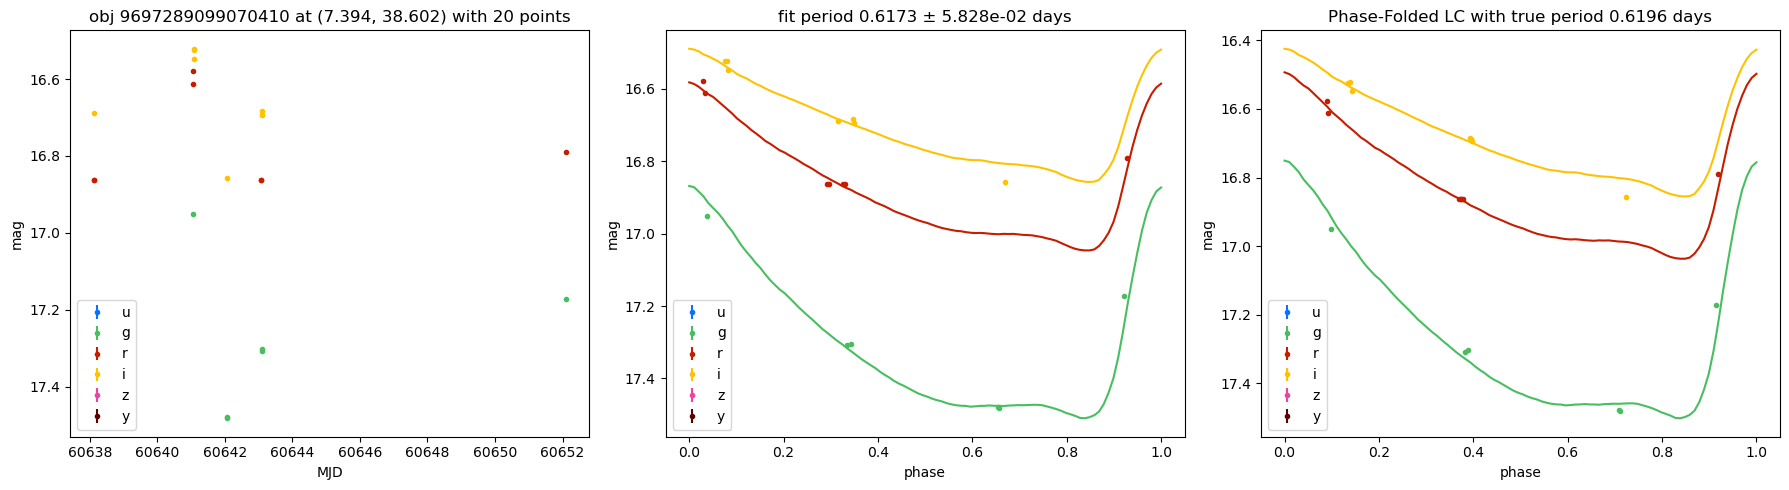

In [13]:
_ = fit_and_plot(xdf, xdf.index[0], true_df=True, p_true = float(xdf.PF.iloc[0]))